# Fase 1 — Exploración de extractores de embeddings

Compara los extractores LM (off-the-shelf) contra el **baseline tabular** de la Fase 0
(XGBoost-Cox sobre las 12 features crudas, test C-index ~0.755 = *la barra a superar*).

Para cada extractor evaluamos 3 conjuntos de features con la MISMA cabeza XGBoost-Cox y el
MISMO split congelado:
- **tab**  — las 100 columnas tabulares (Fase 0)
- **emb**  — solo el embedding del prompt leakage-safe
- **both** — `emb ⊕ tab` (concatenado) → mide *complementariedad*

Pregunta central: ¿`emb` supera a `tab`? y sobre todo ¿`both` > `tab` (el embedding aporta señal nueva)?

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = REPO / "results"
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("Repo   :", REPO)
print("Results:", RESULTS)

Repo   : /media/drive/daniela/Projects/EmbeddingBiomarker
Results: /media/drive/daniela/Projects/EmbeddingBiomarker/results


## 1. ¿Qué hay en `results/`?

Cada corrida persiste un JSON. Convención de nombres:
- `baseline_tabular.json` — Fase 0 (Cox-PH, RSF, XGBoost-Cox).
- `embedding_grid__<modelo>.json` — Fase 1, un archivo por extractor.

In [2]:
for p in sorted(RESULTS.glob("*.json")):
    print(f"{p.name:38s} {p.stat().st_size:>7d} B")

baseline_tabular.json                     1452 B
embedding_grid__medcpt.json               1568 B
embedding_grid__medcpt_cls.json           1567 B
embedding_grid__medcpt_last.json          2613 B
embedding_grid__medgemma15.json           2626 B


## 2. Cargar resultados

In [3]:
baseline = json.loads((RESULTS / "baseline_tabular.json").read_text())
grids = {p.stem.replace("embedding_grid__", ""): json.loads(p.read_text())
         for p in sorted(RESULTS.glob("embedding_grid__*.json"))}
print("Modelos tabulares :", list(baseline["models"]))
print("Extractores (emb) :", list(grids))
for m, d in grids.items():
    print(f"   {m}: template={d.get('template_id')} pooling={d.get('pooling')} dim={d.get('emb_dim')}")

Modelos tabulares : ['coxph', 'rsf', 'xgboost_cox']
Extractores (emb) : ['medcpt', 'medcpt_cls', 'medcpt_last', 'medgemma15']
   medcpt: template=ctx_v1 pooling=mean dim=768
   medcpt_cls: template=ctx_v1 pooling=cls dim=768
   medcpt_last: template=ctx_v1 pooling=last dim=768
   medgemma15: template=ctx_v1 pooling=mean dim=2560


## 3. Tabla larga (tidy) con todo

In [4]:
rows = []
for m, d in baseline["models"].items():
    rows.append({"source": "tabular", "model": m, "feature_set": "tab",
                 "pooling": None, "val": d["c_index"]["val"], "test": d["c_index"]["test"]})
for model, d in grids.items():
    for fs, r in d["feature_sets"].items():
        rows.append({"source": "embedding", "model": model, "feature_set": fs,
                     "pooling": d.get("pooling"),
                     "val": r["c_index"]["val"], "test": r["c_index"]["test"]})
df = pd.DataFrame(rows)
df.sort_values("test", ascending=False).reset_index(drop=True)

,source,model,feature_set,pooling,val,test
0,embedding,medgemma15,both,mean,0.7576,0.7649
1,embedding,medcpt_last,both,last,0.7445,0.7552
2,tabular,xgboost_cox,tab,None,0.7477,0.7549
3,embedding,medcpt_last,tab,last,0.7477,0.7549
4,embedding,medcpt_cls,tab,cls,0.7477,0.7549
5,embedding,medcpt,tab,mean,0.7477,0.7549
6,embedding,medgemma15,tab,mean,0.7477,0.7549
7,embedding,medcpt_cls,both,cls,0.7433,0.7541
8,embedding,medcpt,both,mean,0.7479,0.7526
9,embedding,medgemma15,emb,mean,0.7379,0.7503


## 4. ¿Superan los embeddings al tabular?

La barra es el XGBoost-Cox tabular. Lectura del delta:
- `emb − tab` < 0 → el embedding **solo** pierde contra la tabla.
- `both − tab` ≈ 0 → no hay complementariedad (el embedding no añade nada sobre las 12 features).
- `both − tab` > 0 → el embedding **sí aporta señal nueva** sobre las 12 features tabulares.

In [5]:
TAB = baseline["models"]["xgboost_cox"]["c_index"]["test"]
print(f"Barra a superar (XGBoost-Cox tabular, test C-index): {TAB:.4f}\n")

piv = (df[df.source == "embedding"]
       .pivot_table(index="model", columns="feature_set", values="test"))
piv["emb-tab"] = piv["emb"] - TAB
piv["both-tab (complementariedad)"] = piv["both"] - TAB
piv

Barra a superar (XGBoost-Cox tabular, test C-index): 0.7549



feature_set,both,emb,tab,emb-tab,both-tab (complementariedad)
model,,,,,
medcpt,0.7526,0.7177,0.7549,-0.0372,-0.0024
medcpt_cls,0.7541,0.7202,0.7549,-0.0347,-0.0008
medcpt_last,0.7552,0.7189,0.7549,-0.0360,0.0003
medgemma15,0.7649,0.7503,0.7549,-0.0046,0.0099


### 4b. ¿Es real la complementariedad? — bootstrap CI pareado del delta `both − tab`

1000 réplicas remuestreando el **test** con reemplazo, **modelo fijo**, los **mismos índices** para `both` y `tab` en cada réplica (pareado, porque comparten pacientes y las 100 columnas tabulares). Si el IC excluye 0, el embedding aporta señal real sobre las 12 features.

In [6]:
# Bootstrap pareado del delta `both - tab` (test resampleado, modelo fijo).
# Solo aparece para los modelos corridos con --n-boot > 0 (CIs persistidos en el JSON).
ci_rows = []
for model, d in grids.items():
    deltas = d.get("delta_vs_tab_test") or {}
    bt = deltas.get("both_minus_tab")
    if bt is None:
        continue
    sig = "sí ✅" if bt["ci_low"] > 0 else ("peor" if bt["ci_high"] < 0 else "no")
    ci_rows.append({
        "model": model,
        "both-tab": bt["point"],
        "ci_low": bt["ci_low"], "ci_high": bt["ci_high"],
        "p(>0)": bt["p_gt0"], "n_boot": bt["n_boot"],
        "significativo": sig,
    })
ci_df = pd.DataFrame(ci_rows).sort_values("both-tab", ascending=False).reset_index(drop=True)
ci_df if len(ci_df) else "No hay CIs persistidos todavía (re-corre 22_cox_grid.py con --n-boot 1000)."

,model,both-tab,ci_low,ci_high,p(>0),n_boot,significativo
0,medgemma15,0.0099,0.0032,0.0172,0.9960,1000,sí ✅
1,medcpt_last,0.0003,-0.0062,0.0068,0.5210,1000,no


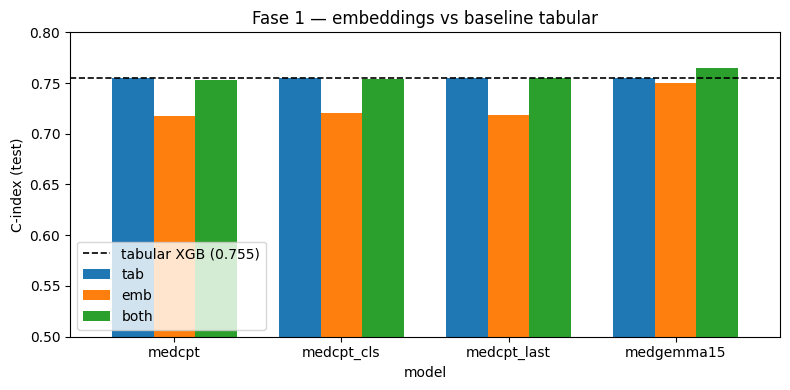

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sub = df[df.source == "embedding"].pivot_table(index="model", columns="feature_set", values="test")
sub.reindex(columns=["tab", "emb", "both"]).plot.bar(ax=ax, width=0.75)
ax.axhline(TAB, ls="--", color="k", lw=1.2, label=f"tabular XGB ({TAB:.3f})")
ax.set_ylabel("C-index (test)")
ax.set_ylim(0.5, 0.8)
ax.set_title("Fase 1 — embeddings vs baseline tabular")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Desempeño por tipo de cáncer (test)

In [8]:
pc_rows = []
for model, d in grids.items():
    for fs, r in d["feature_sets"].items():
        for ct, v in r.get("c_index_per_cancer_test", {}).items():
            pc_rows.append({"model": model, "feature_set": fs, "cancer": ct, "test": v})
# incluir tabular Fase 0 como referencia
for ct, v in baseline["models"]["xgboost_cox"]["c_index_per_cancer_test"].items():
    pc_rows.append({"model": "tabular(xgb)", "feature_set": "tab", "cancer": ct, "test": v})
pc = pd.DataFrame(pc_rows)
pc.pivot_table(index="cancer", columns=["model", "feature_set"], values="test")

model                      medcpt               medcpt_cls                \
feature_set                  both    emb    tab       both    emb    tab   
cancer                                                                     
Breast Cancer              0.7773 0.7463 0.7821     0.7731 0.7503 0.7821   
Colorectal Cancer          0.7471 0.7135 0.7399     0.7504 0.7131 0.7399   
Non-Small Cell Lung Cancer 0.7181 0.6601 0.7349     0.7228 0.6658 0.7349   
Pancreatic Cancer          0.6640 0.6364 0.6494     0.6627 0.6299 0.6494   
Prostate Cancer            0.7929 0.7635 0.7707     0.7960 0.7659 0.7707   

model                      medcpt_last               medgemma15                \
feature_set                       both    emb    tab       both    emb    tab   
cancer                                                                          
Breast Cancer                   0.7770 0.7445 0.7821     0.7945 0.7754 0.7821   
Colorectal Cancer               0.7484 0.7142 0.7399     0.7499 0.7413 0.7399   
Non-Small Cell Lung Cancer      0.7222 0.6625 0.7349     0.7367 0.7083 0.7349   
Pancreatic Cancer               0.6640 0.6346 0.6494     0.6879 0.6943 0.6494   
Prostate Cancer                 0.7967 0.7720 0.7707     0.7875 0.7760 0.7707   

model                      tabular(xgb)  
feature_set                         tab  
cancer                                   
Breast Cancer                    0.7821  
Colorectal Cancer                0.7399  
Non-Small Cell Lung Cancer       0.7349  
Pancreatic Cancer                0.6494  
Prostate Cancer                  0.7707

## 6. Interpretación (estado actual)

**El pooling NO es la palanca; el extractor SÍ.**

- **MedCPT (768d, biomédico-retrieval)** — los 3 poolings (`mean`/`cls`/`last`) dan `emb` 0.7177–0.7202, todos **por debajo** del tabular (0.7549), y `both` ≈ la barra (−0.0024 … +0.0003). El prompt es un *re-encoding lossy* de las mismas 12 features y MedCPT no extrae señal nueva. Cambiar el pooling mueve <0.003 → ruido.
- **MedGemma-1.5-4B (2560d, médico-instruido)** — `emb` sube a **0.7503** (casi cierra la brecha, −0.0046) y, por primera vez, `both` = **0.7649** supera la barra con **complementariedad +0.0099** (val también: 0.7477 → 0.7576). Un extractor más fuerte sí extrae mejor de las **mismas** 12 features.

→ El cuello de botella diagnosticado era el **extractor off-the-shelf**, no la riqueza del prompt (ya lleva mutaciones+tratamientos como texto, más info cruda que el multi-hot tabular). La palanca real es **extractor más fuerte / fine-tuning survival-aware**, NO templates más ricos.

**Por cáncer (MedGemma `both` vs tabular):** aporte consistente en los 5 tumores, mayor en páncreas **+0.0385** (el más difícil para la tabla, 0.6494 → 0.6879), próstata +0.0168 y mama +0.0124.

**Confirmación estadística (bootstrap pareado, 1000 réplicas, test resampleado con modelo fijo):** la complementariedad de MedGemma es real — `both − tab` = **+0.0099, IC 95% [+0.0032, +0.0172], p(>0)=0.996 → el IC excluye 0**. En cambio el mejor MedCPT (`last`) da `both − tab` = +0.0003, IC [−0.0062, +0.0068], p=0.521 → nulo. `emb` solo de MedGemma (−0.0046, IC [−0.0146, +0.0061], p=0.164) es estadísticamente **indistinguible** de la barra: no la supera, pero tampoco es peor. (Implementado en `survival.py::concordance_delta_ci` + `scripts/22_cox_grid.py`; ver celda siguiente.)

**Próximos extractores a llenar en la rejilla:** SmolLM-135M, Llama-3.2-3B (CPU/Colab). Y el paso de mayor techo: **fine-tuning survival-aware del extractor** (paso 13 del plan).